# YOLOv8n PCB Defect Detection -- Fine-tuning

Fine-tunes YOLOv8n on the PCB defect dataset (6 classes: Missing Hole, Mouse Bite,
Open Circuit, Short, Spur, Spurious Copper). Dataset is re-split 80/10/10
(train/val/test) with a fixed seed, discarding any pre-existing split.

Reference: Redmon et al. (2016) "You Only Look Once: Unified, Real-Time Object Detection"
https://arxiv.org/abs/1506.02640

## 1. Install and imports

In [2]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.2 MB/s eta 0:00:0000:01


In [4]:
import os
import random
import shutil
from pathlib import Path

import numpy as np
import yaml
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

INPUT_DIR = Path("/kaggle/input/datasets/norbertelter/pcb-defect-dataset/pcb-defect-dataset")
WORK_DIR    = Path("/kaggle/working")
DATASET_DIR = WORK_DIR / "pcb_dataset"
RUNS_DIR    = WORK_DIR / "runs"
PLOTS_DIR   = WORK_DIR / "plots"

for d in [DATASET_DIR, RUNS_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Ultralytics version:", __import__("ultralytics").__version__)
print("Input dir contents:")
for p in sorted(INPUT_DIR.rglob("*"))[:30]:
    print(" ", p.relative_to(INPUT_DIR))

Ultralytics version: 8.4.33
Input dir contents:
  data.yaml
  test
  test/images
  test/images/l_light_01_missing_hole_04_2_600.jpg
  test/images/l_light_01_missing_hole_07_2_600.jpg
  test/images/l_light_01_missing_hole_08_1_600.jpg
  test/images/l_light_01_missing_hole_10_2_600.jpg
  test/images/l_light_01_missing_hole_14_4_600.jpg
  test/images/l_light_01_missing_hole_18_1_600.jpg
  test/images/l_light_01_missing_hole_18_3_600.jpg
  test/images/l_light_01_mouse_bite_02_2_600.jpg
  test/images/l_light_01_mouse_bite_05_2_600.jpg
  test/images/l_light_01_mouse_bite_07_2_600.jpg
  test/images/l_light_01_mouse_bite_07_3_600.jpg
  test/images/l_light_01_open_circuit_02_1_600.jpg
  test/images/l_light_01_open_circuit_13_2_600.jpg
  test/images/l_light_01_short_03_1_600.jpg
  test/images/l_light_01_short_06_3_600.jpg
  test/images/l_light_01_short_10_2_600.jpg
  test/images/l_light_01_short_11_2_600.jpg
  test/images/l_light_01_short_13_2_600.jpg
  test/images/l_light_01_short_14_1_600.jpg


In [5]:
print(open("/kaggle/input/datasets/norbertelter/pcb-defect-dataset/pcb-defect-dataset/data.yaml").read())
print()
all_dirs = sorted(set(p.parent.relative_to(INPUT_DIR) for p in INPUT_DIR.rglob("*") if p.is_file()))
for d in all_dirs:
    print(d)

path: ../pcb-defect-dataset
train: train
val: val
test: test

names:
  0: mouse_bite
  1: spur
  2: missing_hole
  3: short
  4: open_circuit
  5: spurious_copper


.
test/images
test/labels
train/images
train/labels
val/images
val/labels


## 2. Inspect dataset structure

In [6]:
# Count images and labels to understand the layout before re-splitting.
images = sorted(INPUT_DIR.rglob("*.jpg")) + sorted(INPUT_DIR.rglob("*.png")) + sorted(INPUT_DIR.rglob("*.JPG"))
labels = sorted(INPUT_DIR.rglob("*.txt"))

# Filter out any non-annotation txt files (e.g. classes.txt, README).
labels = [l for l in labels if l.stem != "classes" and l.stem != "README"]

print(f"Total images found: {len(images)}")
print(f"Total label files found: {len(labels)}")
print()

# Show unique class ids present in labels.
class_ids_found = set()
for lf in labels[:500]:  # sample first 500 for speed
    for line in lf.read_text().strip().splitlines():
        if line.strip():
            class_ids_found.add(int(line.split()[0]))
print(f"Class IDs present (sample): {sorted(class_ids_found)}")

# Show a few label file contents.
print()
print("Sample label file:", labels[0])
print(labels[0].read_text()[:300])

Total images found: 10668
Total label files found: 10668

Class IDs present (sample): [0, 1, 2, 3, 4, 5]

Sample label file: /kaggle/input/datasets/norbertelter/pcb-defect-dataset/pcb-defect-dataset/test/labels/l_light_01_missing_hole_04_2_600.txt
2 0.3808 0.1575 0.0483 0.0583
2 0.2600 0.4242 0.0600 0.0583



## 3. Match images to labels and re-split 80/10/10

In [7]:
# Build matched (image, label) pairs. Only keep pairs where both exist.
label_stems = {l.stem: l for l in labels}
pairs = []
for img in images:
    if img.stem in label_stems:
        pairs.append((img, label_stems[img.stem]))

print(f"Matched image-label pairs: {len(pairs)}")
print(f"Images without labels (skipped): {len(images) - len(pairs)}")

# Shuffle and split 80/10/10.
random.shuffle(pairs)
n = len(pairs)
n_train = int(0.8 * n)
n_val   = int(0.1 * n)

splits = {
    "train": pairs[:n_train],
    "val":   pairs[n_train:n_train + n_val],
    "test":  pairs[n_train + n_val:],
}

for split, split_pairs in splits.items():
    print(f"{split:>6}: {len(split_pairs)} pairs")

Matched image-label pairs: 8001
Images without labels (skipped): 2667
 train: 6400 pairs
   val: 800 pairs
  test: 801 pairs


## 4. Copy files into YOLO directory structure

In [8]:
# YOLO expects:
#   dataset/images/train/*.jpg
#   dataset/labels/train/*.txt
#   (same for val and test)

for split, split_pairs in splits.items():
    img_dir = DATASET_DIR / "images" / split
    lbl_dir = DATASET_DIR / "labels" / split
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)

    for img_path, lbl_path in split_pairs:
        shutil.copy(img_path, img_dir / img_path.name)
        shutil.copy(lbl_path, lbl_dir / lbl_path.name)

print("Directory structure created:")
for split in ["train", "val", "test"]:
    n_imgs = len(list((DATASET_DIR / "images" / split).iterdir()))
    n_lbls = len(list((DATASET_DIR / "labels" / split).iterdir()))
    print(f"  {split}: {n_imgs} images, {n_lbls} labels")

Directory structure created:
  train: 6400 images, 6400 labels
  val: 800 images, 800 labels
  test: 801 images, 801 labels


## 5. Create dataset.yaml

In [9]:
# Class names for the PCB defect dataset.
# Adjust if the inspect cell above shows different class ordering.
CLASS_NAMES = [
    "mouse_bite",
    "spur",
    "missing_hole",
    "short",
    "open_circuit",
    "spurious_copper",
]

dataset_yaml = {
    "path":  str(DATASET_DIR),
    "train": "images/train",
    "val":   "images/val",
    "test":  "images/test",
    "nc":    len(CLASS_NAMES),
    "names": CLASS_NAMES,
}

yaml_path = DATASET_DIR / "dataset.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False, sort_keys=False)

print("dataset.yaml written:")
print(yaml_path.read_text())

dataset.yaml written:
path: /kaggle/working/pcb_dataset
train: images/train
val: images/val
test: images/test
nc: 6
names:
- mouse_bite
- spur
- missing_hole
- short
- open_circuit
- spurious_copper



## 6. Fine-tune YOLOv8n

In [10]:
model = YOLO("yolov8n.pt")

results = model.train(
    data=str(yaml_path),
    epochs=50,
    imgsz=640,
    batch=16,
    seed=SEED,
    project=str(RUNS_DIR),
    name="pcb_yolov8n",
    exist_ok=True,
    verbose=True,
)

print("Training complete.")
print(f"Best weights: {RUNS_DIR}/pcb_yolov8n/weights/best.pt")

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/pcb_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pcb_yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=

## 7. Evaluate on test set

In [11]:
best_weights = RUNS_DIR / "pcb_yolov8n" / "weights" / "best.pt"
eval_model   = YOLO(str(best_weights))

metrics = eval_model.val(
    data=str(yaml_path),
    split="test",
    imgsz=640,
    batch=16,
    project=str(RUNS_DIR),
    name="pcb_eval",
    exist_ok=True,
    verbose=True,
)

print()
print("=" * 50)
print("Test set results")
print("=" * 50)
print(f"mAP@0.5:       {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95:  {metrics.box.map:.4f}")
print(f"Precision:     {metrics.box.mp:.4f}")
print(f"Recall:        {metrics.box.mr:.4f}")
print()
print("Per-class AP@0.5:")
for name, ap in zip(CLASS_NAMES, metrics.box.ap50):
    print(f"  {name:<20} {ap:.4f}")

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1448.1±818.6 MB/s, size: 130.1 KB)
val: Scanning /kaggle/working/pcb_dataset/labels/test... 801 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 801/801 1.5Kit/s 0.5s0.0ss
val: New cache created: /kaggle/working/pcb_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 7.1it/s 7.2s0.1s
                   all        801       1621      0.977      0.984       0.99      0.603
            mouse_bite        143        281      0.975      0.986      0.987      0.599
                  spur        115        240       0.99      0.979      0.992      0.588
          missing_hole        123        233      0.969      0.991      0.992      0.654
                 short        135        280      0.986

## 8. Inference on test samples

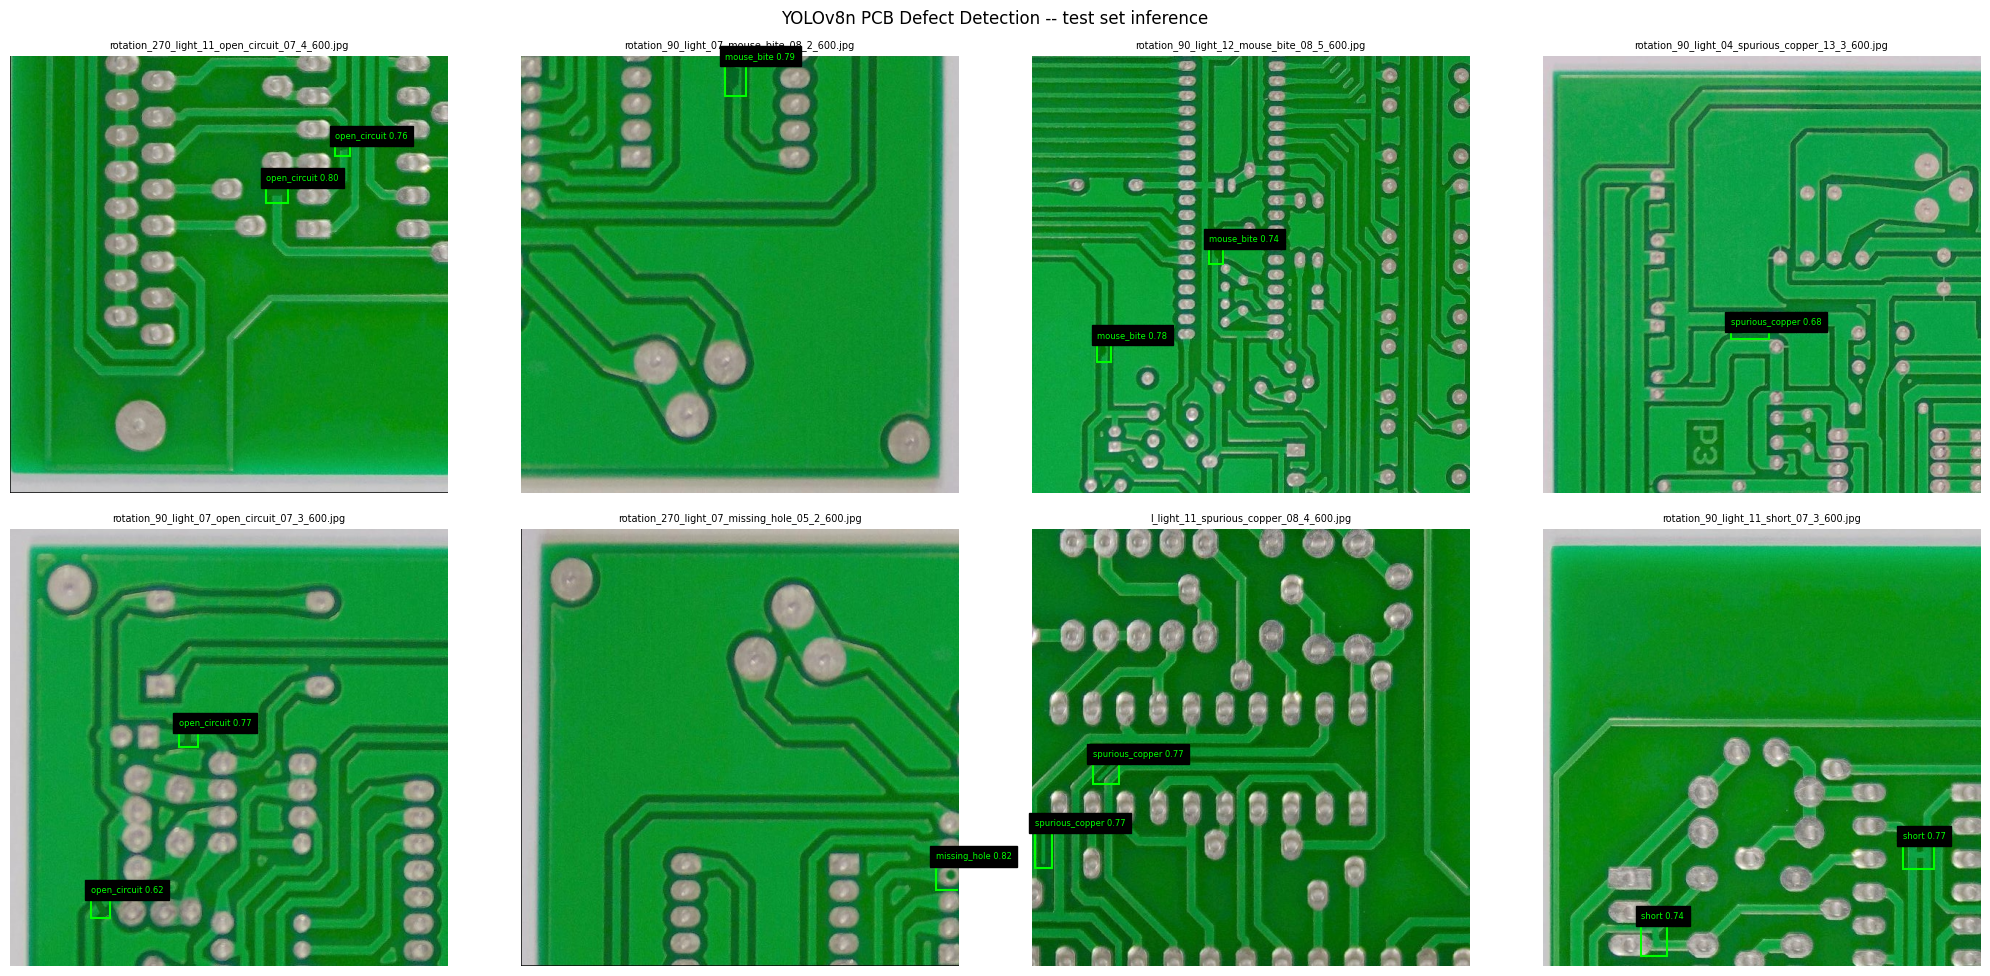

Inference plot saved to /kaggle/working/plots/inference_samples.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Pick 8 random test images.
test_images = sorted((DATASET_DIR / "images" / "test").iterdir())
random.shuffle(test_images)
sample_images = test_images[:8]

# Run inference.
infer_results = eval_model.predict(
    source=[str(p) for p in sample_images],
    imgsz=640,
    conf=0.25,
    iou=0.45,
    verbose=False,
)

# Plot predictions.
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, result, img_path in zip(axes, infer_results, sample_images):
    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(img_path.name, fontsize=7)

    if result.boxes is not None and len(result.boxes):
        img_w, img_h = img.size
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            cls_id = int(box.cls[0])
            conf   = float(box.conf[0])
            label  = f"{CLASS_NAMES[cls_id]} {conf:.2f}"

            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=1.5, edgecolor="lime", facecolor="none",
            )
            ax.add_patch(rect)
            ax.text(x1, max(y1 - 4, 0), label, color="lime",
                    fontsize=6, backgroundcolor="black")

plt.suptitle("YOLOv8n PCB Defect Detection -- test set inference", fontsize=12)
plt.tight_layout()
plot_path = PLOTS_DIR / "inference_samples.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Inference plot saved to {plot_path}")

## 9. Copy outputs for download

In [17]:
# Copy best weights, dataset.yaml, and plots to /kaggle/working root.
shutil.copy(best_weights, WORK_DIR / "best_pcb_yolov8n.pt")
shutil.copy(yaml_path, WORK_DIR / "dataset.yaml")
shutil.copy(plot_path, WORK_DIR / "inference_samples.png")

# Copy training curves from runs dir.
curves_src = RUNS_DIR / "pcb_yolov8n" / "results.png"
if curves_src.exists():
    shutil.copy(curves_src, WORK_DIR / "training_curves.png")

print("Files ready for download:")
for f in sorted(WORK_DIR.glob("*.pt")) + sorted(WORK_DIR.glob("*.yaml")) + sorted(WORK_DIR.glob("*.png")):
    size_mb = f.stat().st_size / (1024**2)
    print(f"  {f.name:<40} {size_mb:.1f} MB")

Files ready for download:
  best_pcb_yolov8n.pt                      6.0 MB
  dataset.yaml                             0.0 MB
  confusion_matrix.png                     0.2 MB
  confusion_matrix_normalized.png          0.2 MB
  inference_samples.png                    5.0 MB
  training_curves.png                      0.2 MB


In [14]:
for f in ["yolo26n.pt", "yolov8n.pt"]:
    p = WORK_DIR / f
    if p.exists():
        p.unlink()
        print(f"Removed {f}")

Removed yolo26n.pt
Removed yolov8n.pt


In [16]:
labels_plot = RUNS_DIR / "pcb_yolov8n" / "labels.jpg"
if labels_plot.exists():
    shutil.copy(labels_plot, WORK_DIR / "labels_distribution.jpg")

In [20]:
for name in ["confusion_matrix.png", "confusion_matrix_normalized.png", "BoxPR_curve.png", "BoxF1_curve.png"]:
    src = RUNS_DIR / "pcb_yolov8n" / name
    if src.exists():
        shutil.copy(src, WORK_DIR / name)